Processing Neighborhood_SWI vs PE_SWI...
Processing Neighborhood_SWI vs PE_DWI...
Processing Neighborhood_DWI vs PE_DWI...
Processing Neighborhood_DWI vs PE_SWI...


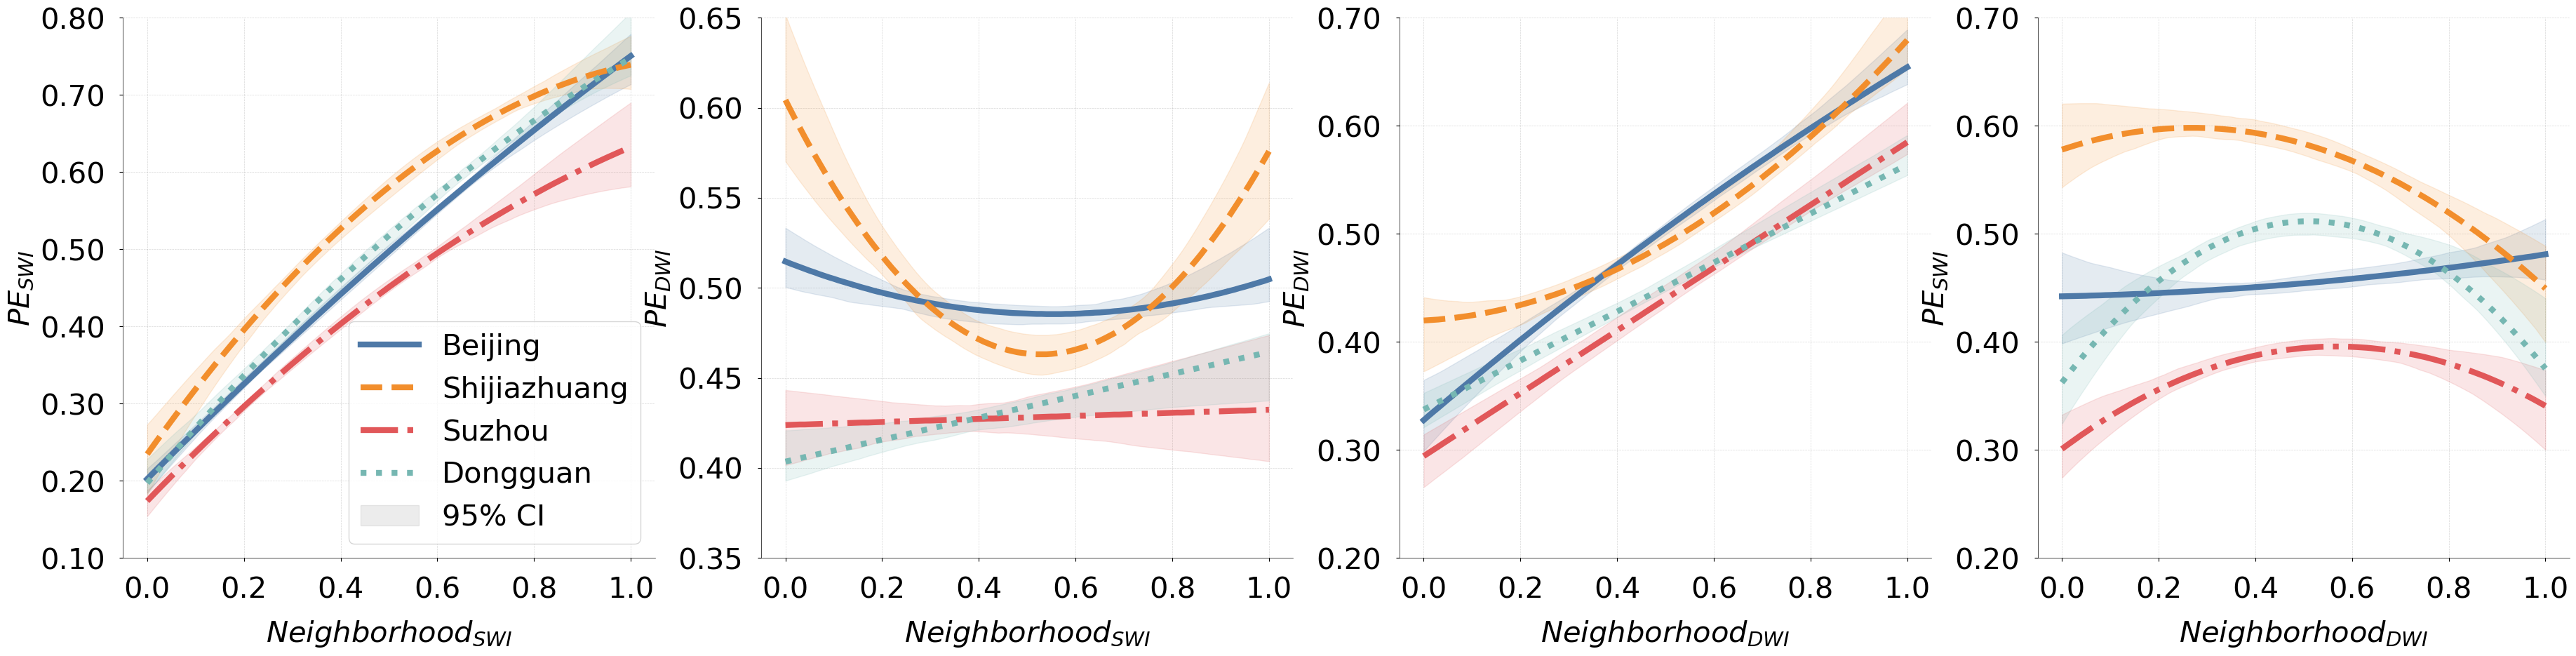

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FormatStrFormatter
import warnings

warnings.filterwarnings("ignore")

COLORS = ['#4E79A7', '#F28E2C', '#E15759', '#76B7B2']
STYPES = ['-', '--', '-.', ':']
WIDTHS = [3, 3, 3, 3]

plt.rcParams['xtick.labelsize'] = 30
plt.rcParams['ytick.labelsize'] = 30
plt.rcParams['axes.labelsize'] = 30
plt.rcParams['legend.fontsize'] = 30

feature_to_label = {
    'Neighborhood_SWI': r'$\mathit{Neighborhood}_{\mathit{SWI}}$',
    'Neighborhood_DWI': r'$\mathit{Neighborhood}_{\mathit{DWI}}$',
    'PE_SWI': r'$\mathit{PE}_{\mathit{SWI}}$',
    'PE_DWI': r'$\mathit{PE}_{\mathit{DWI}}$'
}
plot_cities = ['Beijing', 'Shijiazhuang', 'Suzhou', 'Dongguan']

fig, axs = plt.subplots(1, 4, figsize=(45, 10))
count = -1

for (feature_x, feature_y) in [('Neighborhood_SWI', 'PE_SWI'), ('Neighborhood_SWI', 'PE_DWI'),
                               ('Neighborhood_DWI', 'PE_DWI'), ('Neighborhood_DWI', 'PE_SWI')]:
    count += 1
    print(f"Processing {feature_x} vs {feature_y}...")

    data_df = pd.read_csv(
        rf'E:\experienced walkability across urban forms\Code and Data\source data\individual-level experience\{feature_x} v.s {feature_y} (82 cities).csv')

    ax = axs.flatten()[count]
    for city_dex, city_name in enumerate(plot_cities):

        x_smooth = data_df[feature_x]
        col_name = f'{city_name} (95% CI)'
        extracted = data_df[col_name].str.extract(r'(-?\d+\.\d+)\s*\(\s*(-?\d+\.\d+)\s*,\s*(-?\d+\.\d+)\s*\)')
        extracted = extracted.astype(float)
        y_hat = extracted[0].to_numpy()
        ci_low = extracted[1].to_numpy()
        ci_up = extracted[2].to_numpy()

        ax.fill_between(x_smooth, ci_low, ci_up, color=COLORS[city_dex], alpha=0.15, zorder=2)
        ax.plot(x_smooth, y_hat, color=COLORS[city_dex], linewidth=6, linestyle=STYPES[city_dex],
                label=f'{city_name}', zorder=3)
        ax.set_xlabel(feature_to_label.get(feature_x, feature_x), labelpad=15)
        ax.set_ylabel(feature_to_label.get(feature_y, feature_y), labelpad=5)

        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.3, color='#7f7f7f')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.5)
        ax.spines['bottom'].set_linewidth(0.5)
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        ax.xaxis.set_tick_params(pad=15)
        ax.yaxis.set_tick_params(pad=15)
        ax.set_ylim([0, 1])

        if (feature_x == 'Neighborhood_SWI') & (feature_y == 'PE_SWI'):
            ax.set_ylim([0.1, 0.8])
        if (feature_x == 'Neighborhood_SWI') & (feature_y == 'PE_DWI'):
            ax.set_ylim([0.35, 0.65])
        if (feature_x == 'Neighborhood_DWI') & (feature_y == 'PE_SWI'):
            ax.set_ylim([0.2, 0.70])
        if (feature_x == 'Neighborhood_DWI') & (feature_y == 'PE_DWI'):
            ax.set_ylim([0.2, 0.70])

    if count == 0:
        ci_patch = mpatches.Patch(color='gray', alpha=0.15, label='95% CI')
        ax.legend(handles=ax.lines + [ci_patch], loc='best', fontsize=30)

plt.savefig(f'F:/{feature_x}_{feature_y}.svg', bbox_inches='tight')
plt.show()

Generating heatmap for PE_SWI...
Generating heatmap for PE_DWI...


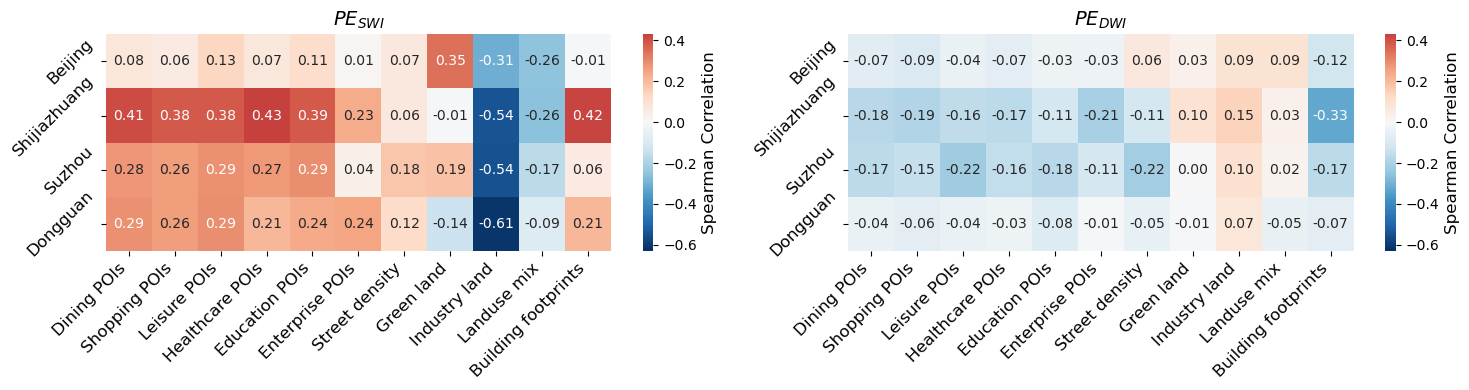

Successfully saved and closed the combined plot.



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

feature_columns = ['Dining POIs', 'Shopping POIs', 'Leisure POIs', 'Healthcare POIs', 'Education POIs',
                   'Enterprise POIs',
                   'Street density', 'Green land', 'Industry land', 'Landuse mix', 'Building footprints']

plot_cities = ['Beijing', 'Shijiazhuang', 'Suzhou', 'Dongguan']

plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

# 创建 1行2列 的画布，稍微加宽以容纳两个 colorbar
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# 统一的颜色范围
vmin_val = -0.63
vmax_val = 0.43

columns_to_plot = ['PE_SWI', 'PE_DWI']

for i, column_name in enumerate(columns_to_plot):
    print(f"Generating heatmap for {column_name}...")

    ax = axes[i]

    rho_df = pd.read_csv(
        rf'E:\experienced walkability across urban forms\Code and Data\source data\individual-level experience\Built environment correlates with {column_name} (82 cities).csv')
    plot_df = rho_df.set_index('city_en').loc[plot_cities, feature_columns].copy()

    # 绘制热力图，开启 cbar
    sns.heatmap(
        plot_df,
        cmap="RdBu_r",
        center=0,
        vmin=vmin_val,  # 统一最小颜色值
        vmax=vmax_val,  # 统一最大颜色值
        annot=True,
        fmt=".2f",
        ax=ax,
        cbar=True,  # 让两张图都显示 Colorbar
        cbar_kws={'label': 'Spearman Correlation'}
    )

    # 分别对两张图的 colorbar 进行格式化
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label("Spearman Correlation", fontsize=12)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=45, ha="right")

    ax.set_ylabel('')

    # 设置标题
    if column_name == 'PE_SWI':
        ax.set_title(r"$\mathit{PE}_{\mathit{SWI}}$", fontsize=14)
    elif column_name == 'PE_DWI':
        ax.set_title(r"$\mathit{PE}_{\mathit{DWI}}$", fontsize=14)

# 统一调整布局并保存
plt.tight_layout()
plt.savefig('F:/Combined_PE_SWI_DWI_heatmap_with_both_cbars.svg', bbox_inches='tight')
plt.show()
plt.close(fig)

print("Successfully saved and closed the combined plot.\n")


Loading data...
Generating 1x2 heatmap for Radial Monocentric...


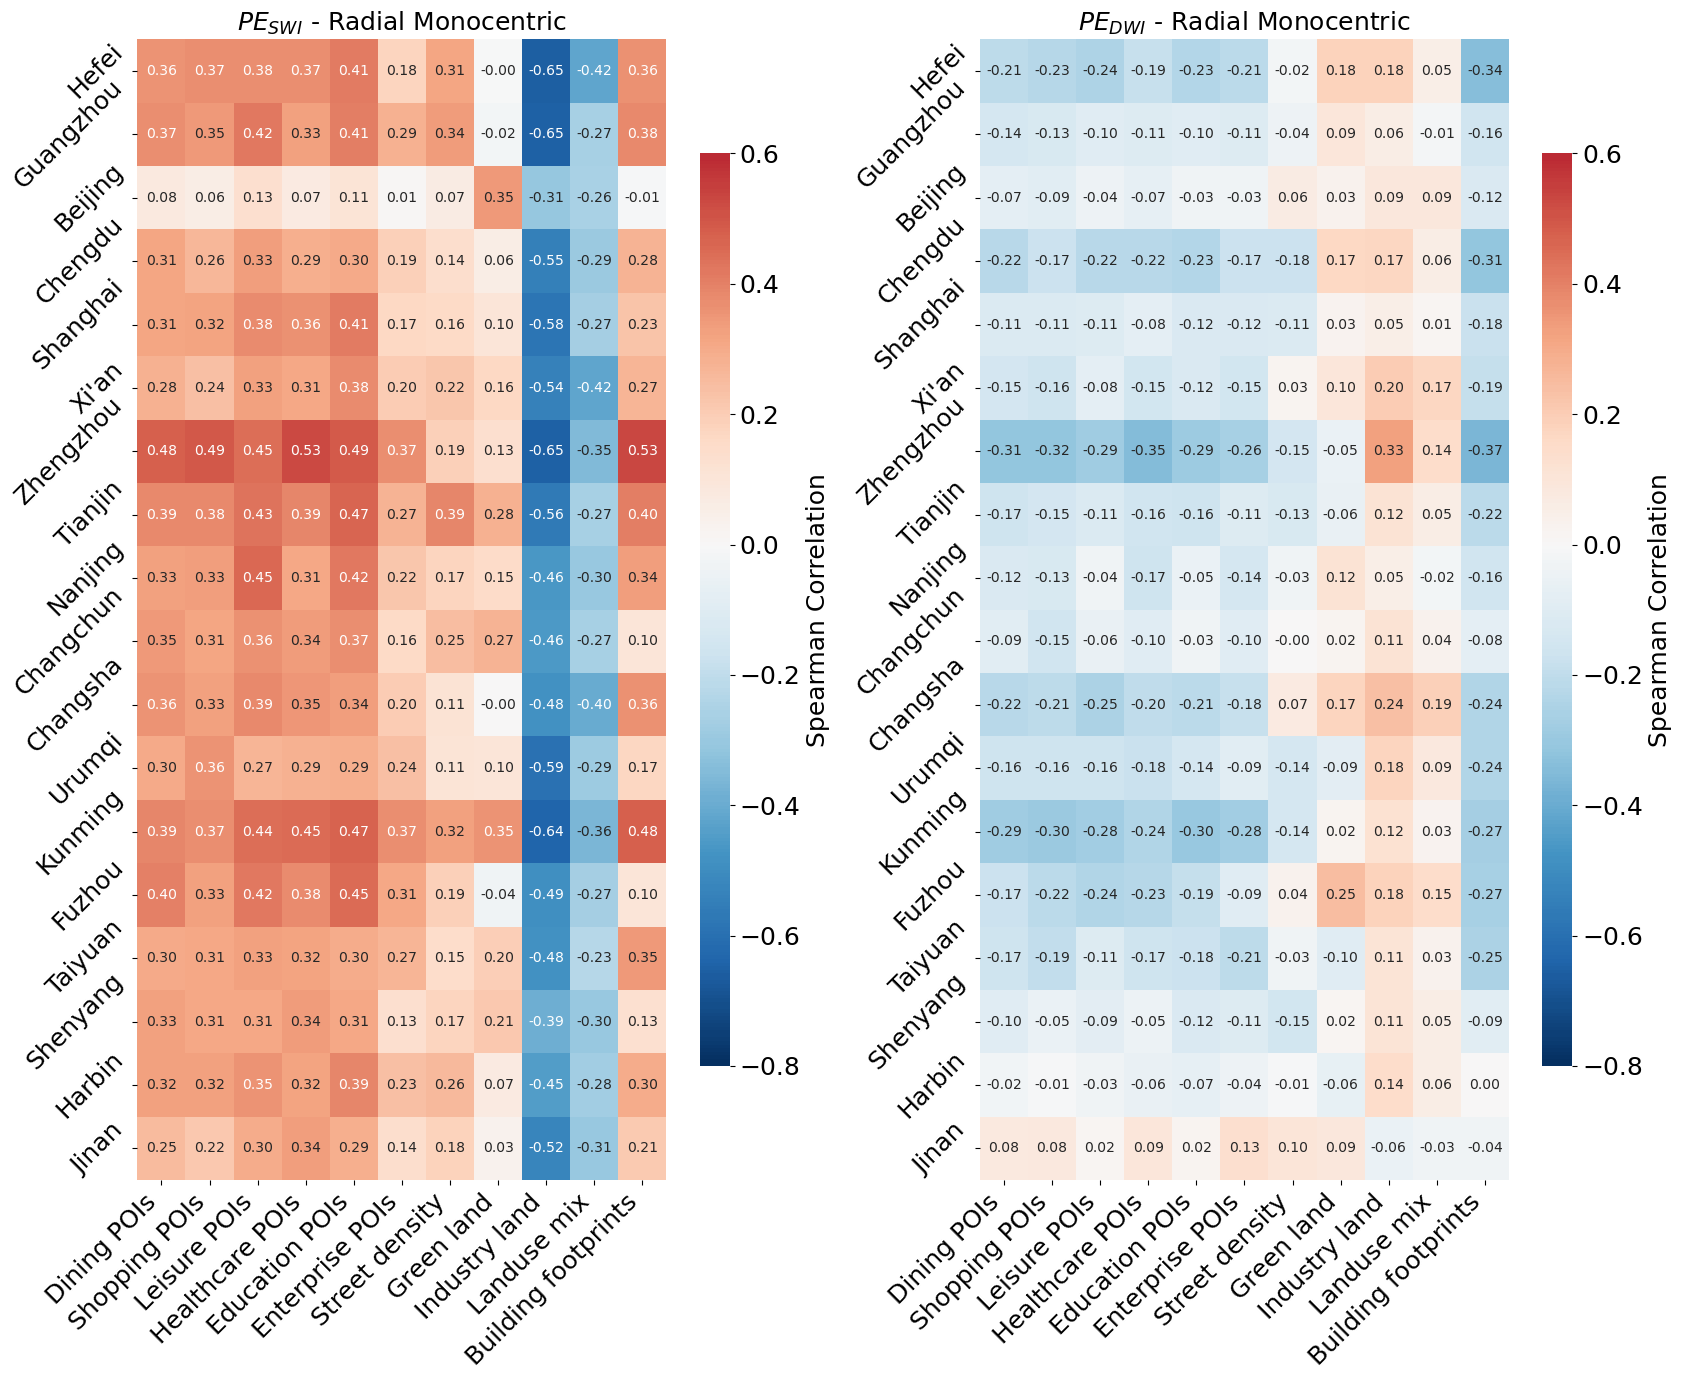

Successfully saved and closed plot for Radial Monocentric.

Generating 1x2 heatmap for Concentric Monocentric...


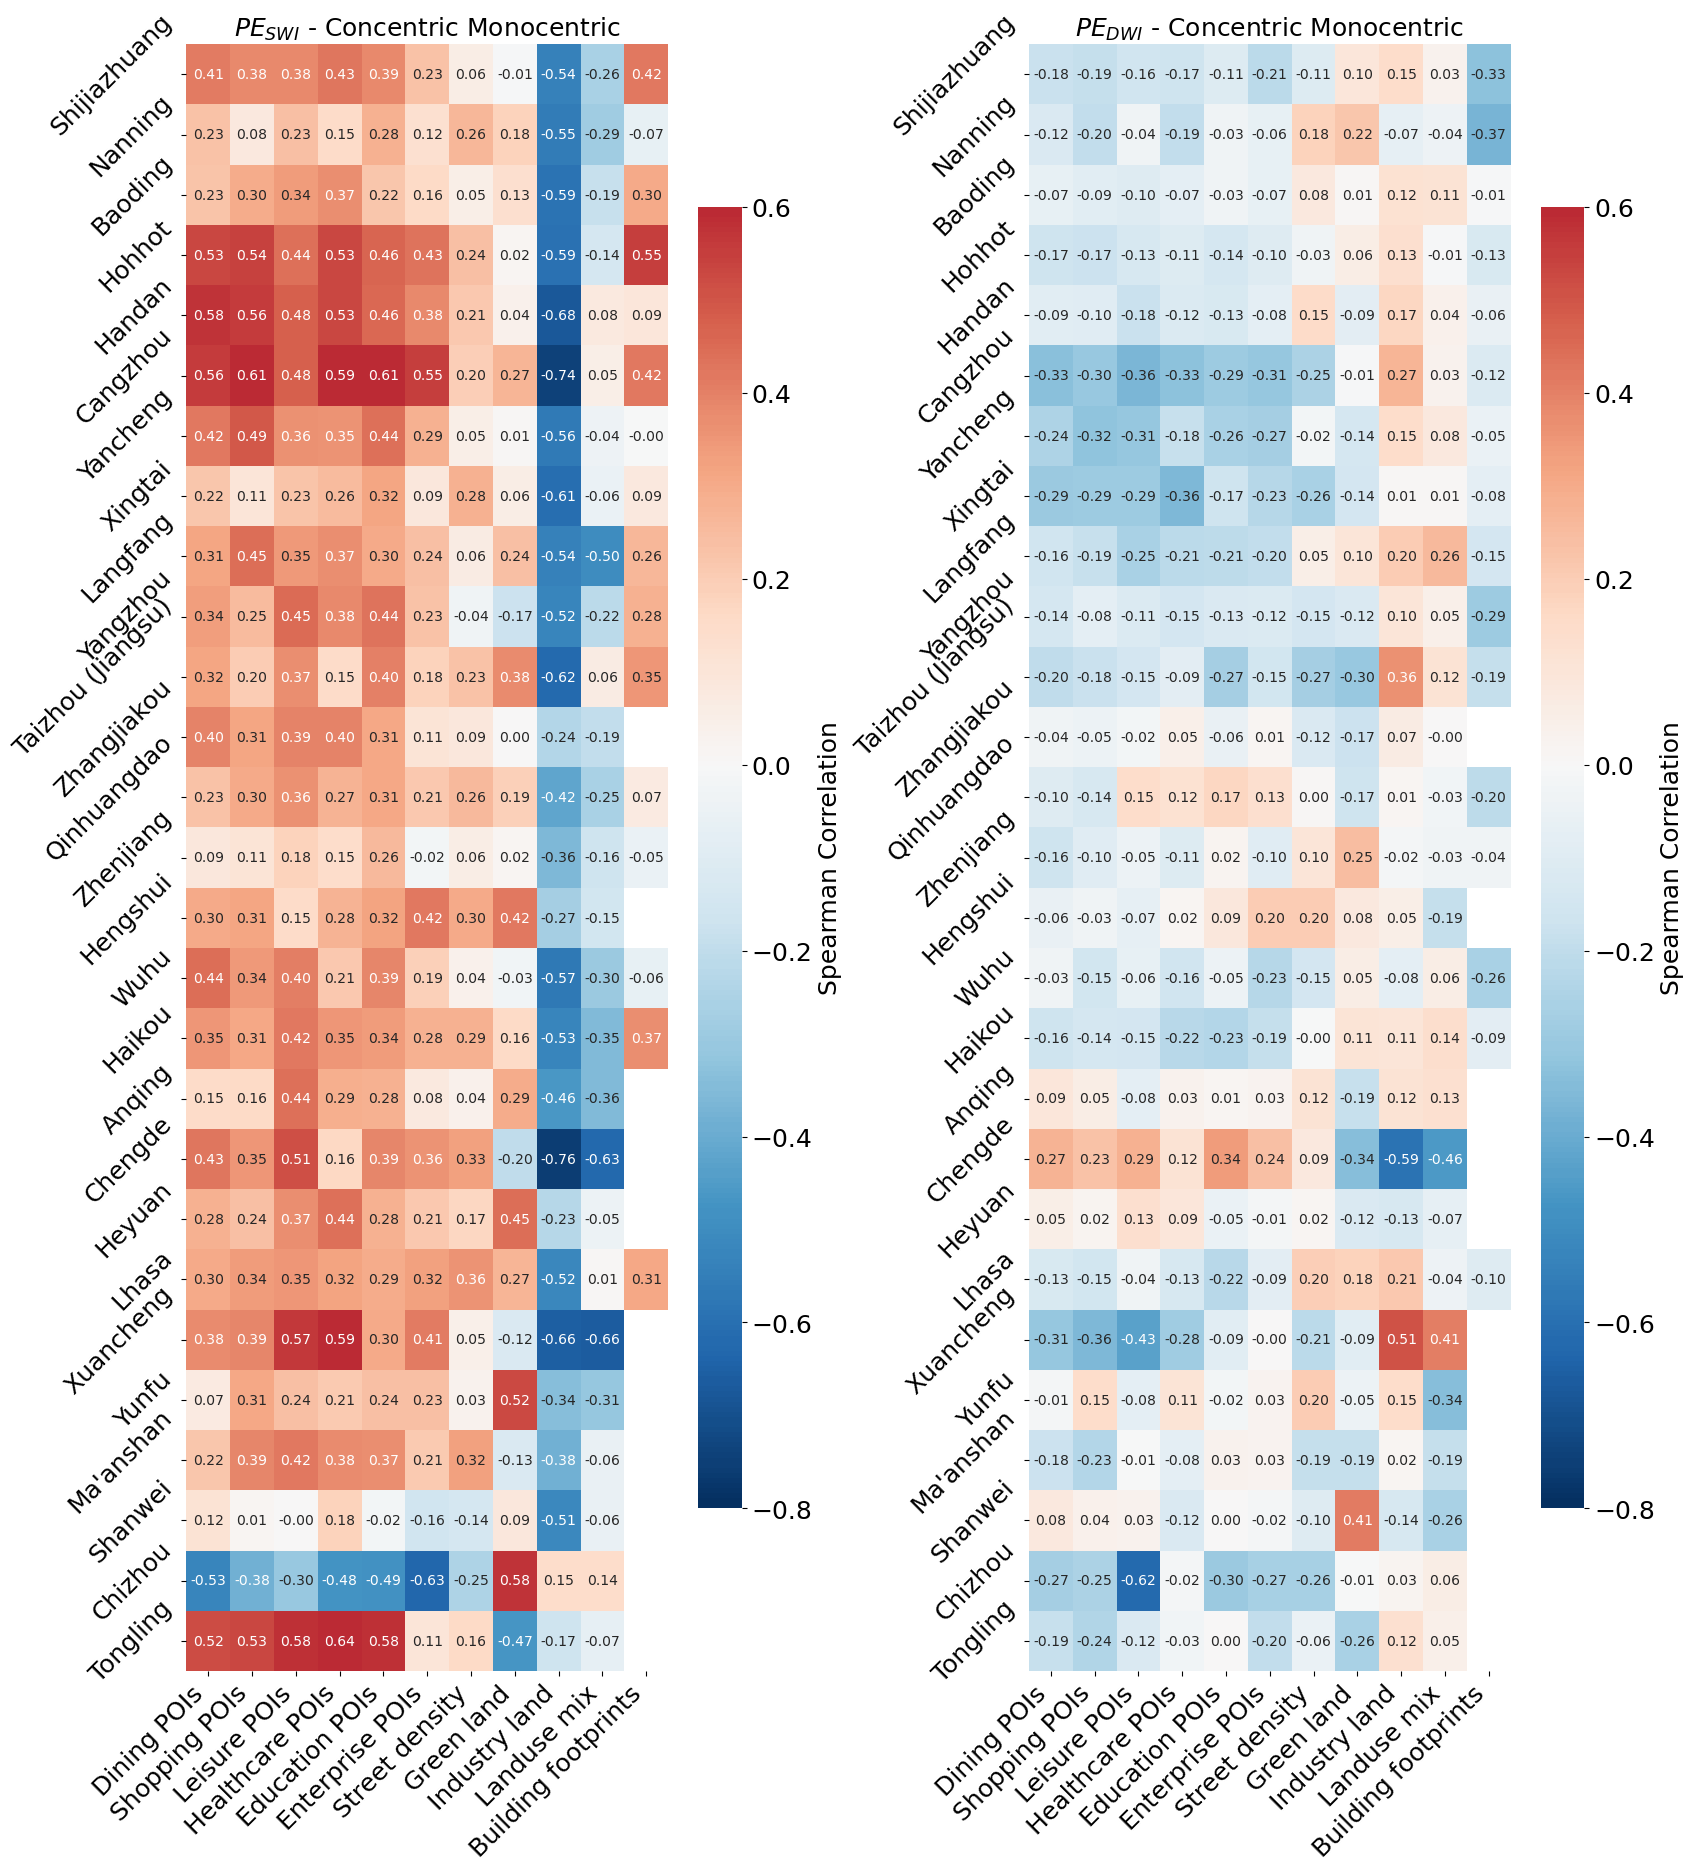

Successfully saved and closed plot for Concentric Monocentric.

Generating 1x2 heatmap for Clustered Polycentric...


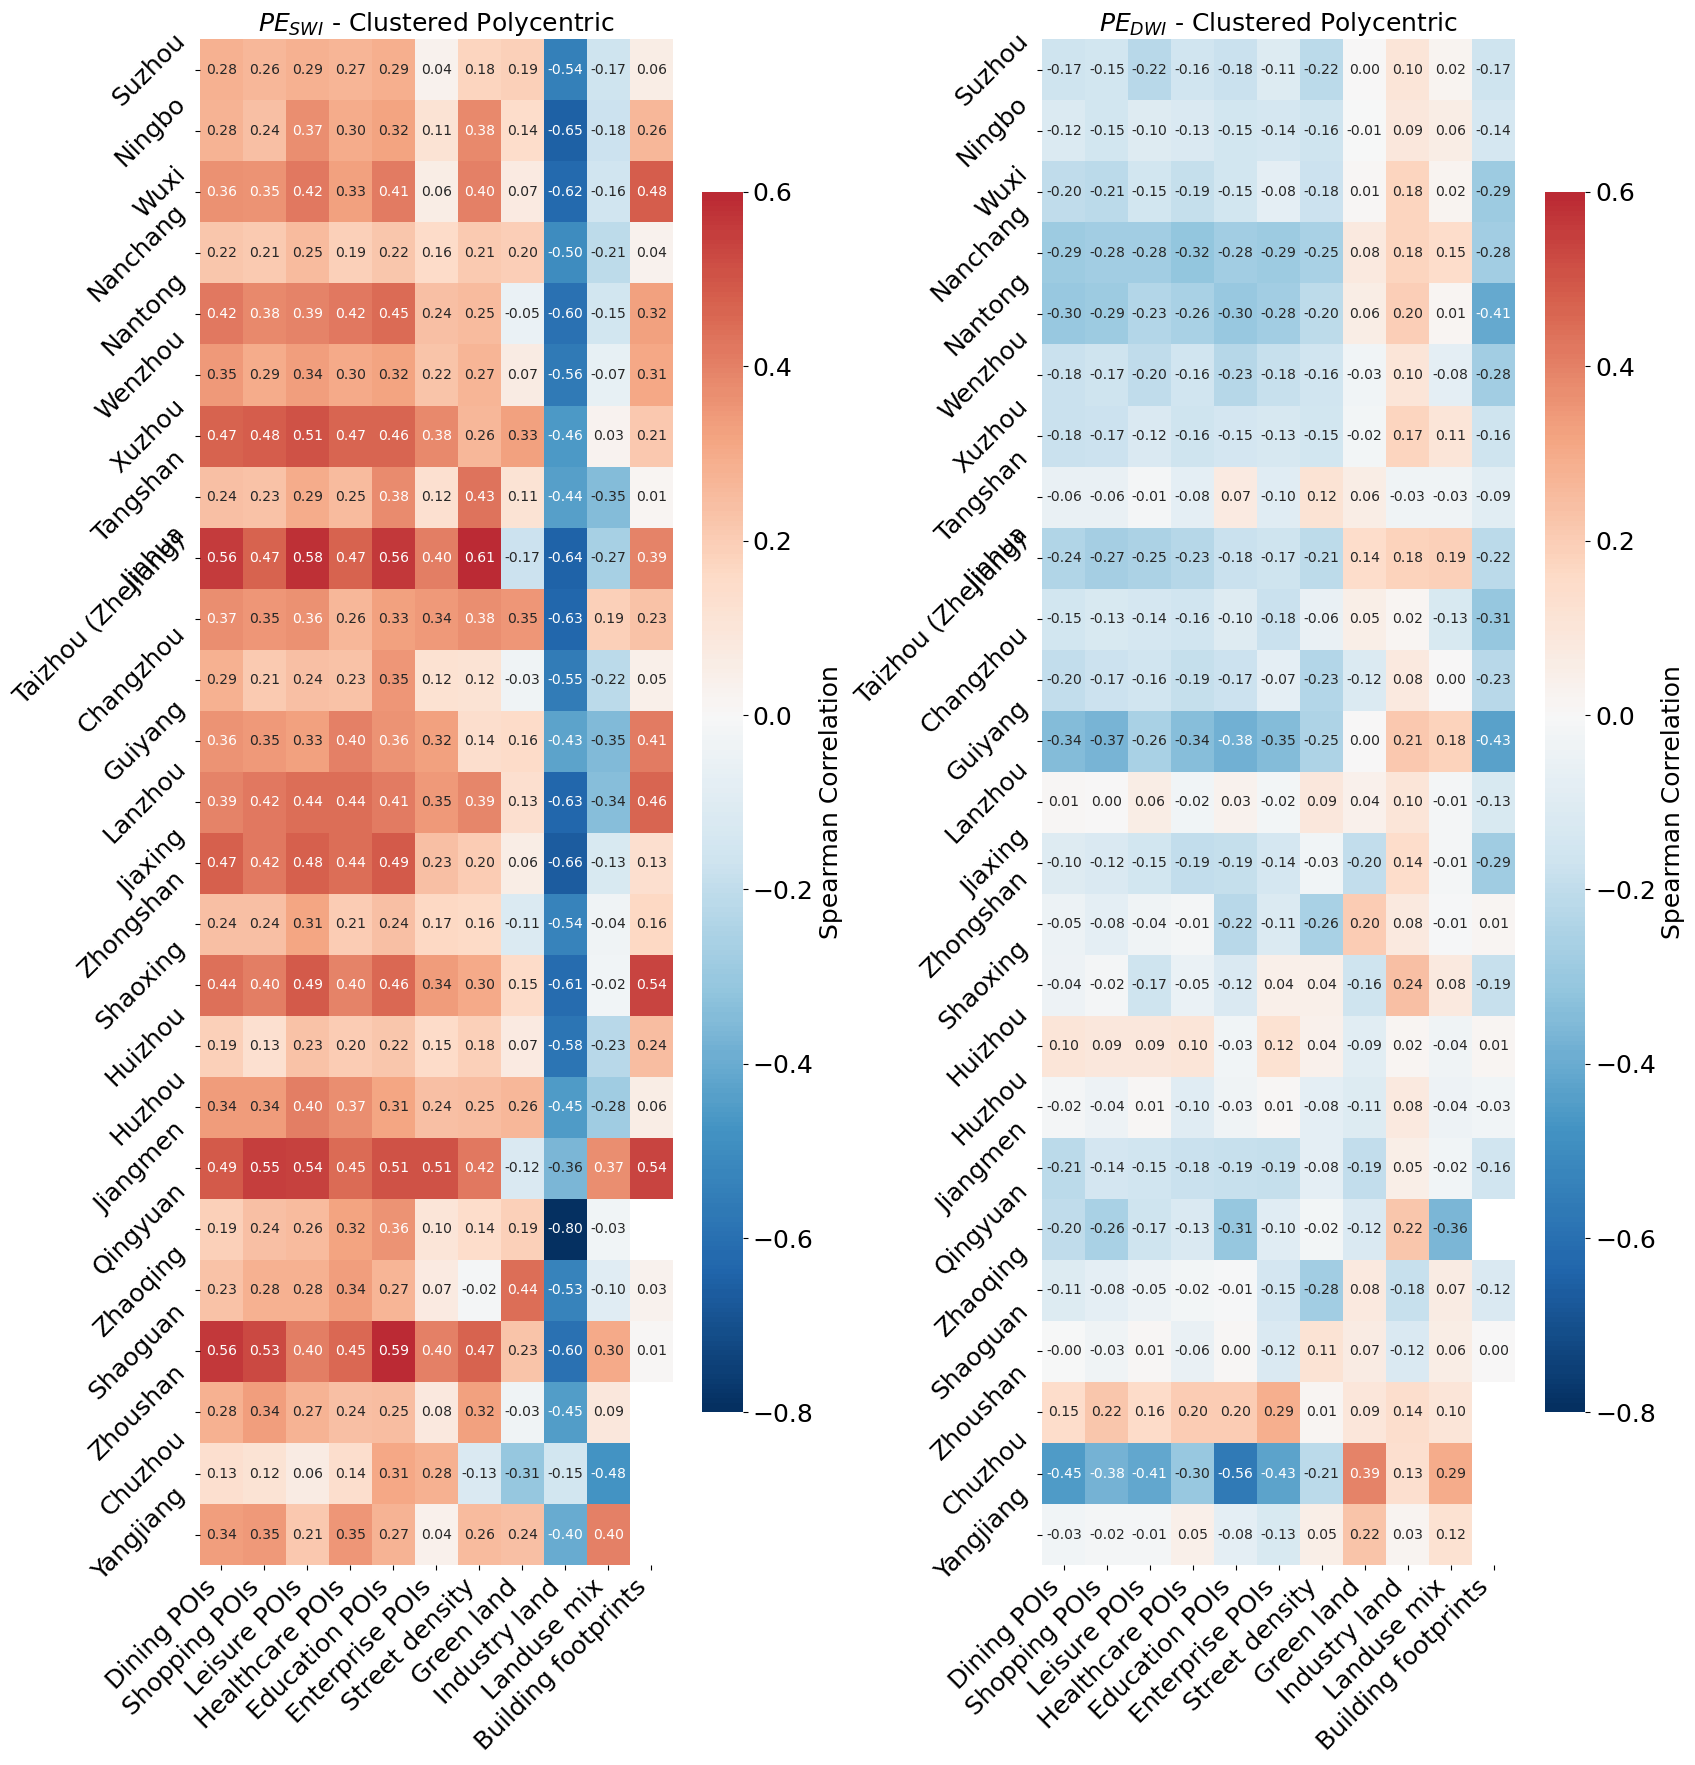

Successfully saved and closed plot for Clustered Polycentric.

Generating 1x2 heatmap for Dispersed Polycentric...


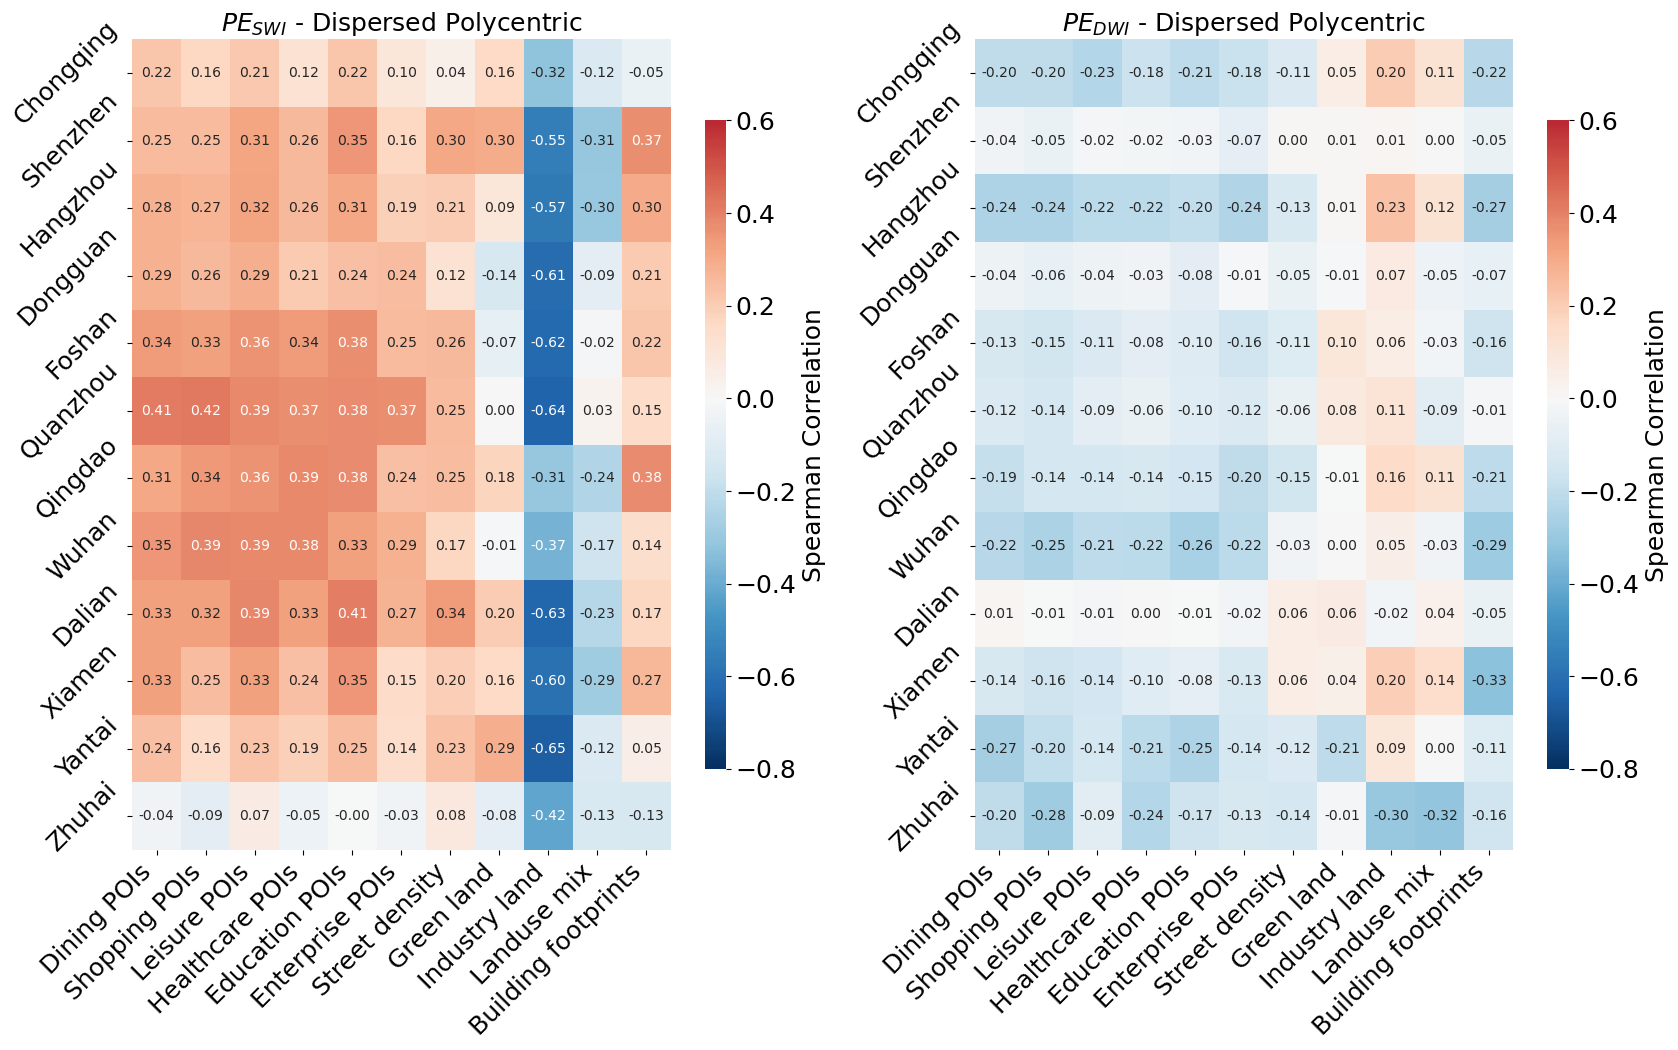

Successfully saved and closed plot for Dispersed Polycentric.



In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

feature_columns = ['Dining POIs', 'Shopping POIs', 'Leisure POIs', 'Healthcare POIs', 'Education POIs',
                   'Enterprise POIs', 'Street density', 'Green land', 'Industry land', 'Landuse mix',
                   'Building footprints']

plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['legend.fontsize'] = 18

urban_forms = [
    'Radial Monocentric',
    'Concentric Monocentric',
    'Clustered Polycentric',
    'Dispersed Polycentric'
]

urban_form_col = 'urban form'

print("Loading data...")
df_dict = {
    'PE_SWI': pd.read_csv(
        rf'E:\experienced walkability across urban forms\Code and Data\source data\individual-level experience\Built environment correlates with PE_SWI (82 cities).csv'),
    'PE_DWI': pd.read_csv(
        rf'E:\experienced walkability across urban forms\Code and Data\source data\individual-level experience\Built environment correlates with PE_DWI (82 cities).csv')
}

vmin_val = -0.8
vmax_val = 0.6

for form in urban_forms:
    print(f"Generating 1x2 heatmap for {form}...")

    num_cities = len(df_dict['PE_SWI'][df_dict['PE_SWI'][urban_form_col] == form])
    fig_height = max(num_cities * 0.55 + 4, 8)

    fig, axes = plt.subplots(1, 2, figsize=(17, fig_height))

    for i, column_name in enumerate(['PE_SWI', 'PE_DWI']):
        ax = axes[i]

        rho_df = df_dict[column_name]
        form_df = rho_df[rho_df[urban_form_col] == form]
        plot_df = form_df.set_index('city_en').loc[:, feature_columns].copy()

        sns.heatmap(
            plot_df,
            cmap="RdBu_r",
            center=0,
            vmin=vmin_val,
            vmax=vmax_val,
            annot=True,
            fmt=".2f",
            ax=ax,
            cbar=True,
            cbar_kws={
                'label': 'Spearman Correlation',
                'shrink': 0.8,
                'aspect': 30
            }
        )

        cbar = ax.collections[0].colorbar
        cbar.ax.tick_params(labelsize=18)
        cbar.set_label("Spearman Correlation", fontsize=18)

        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=45, ha="right")
        ax.set_ylabel('')

        if column_name == 'PE_SWI':
            ax.set_title(rf"$\mathit{{PE}}_{{\mathit{{SWI}}}}$ - {form}", fontsize=18)
        elif column_name == 'PE_DWI':
            ax.set_title(rf"$\mathit{{PE}}_{{\mathit{{DWI}}}}$ - {form}", fontsize=18)

    plt.tight_layout()

    safe_form_name = form.replace(' ', '_')
    plt.savefig(f'F:/{safe_form_name}_heatmap.svg', bbox_inches='tight')
    plt.savefig(f'F:/{safe_form_name}_heatmap.pdf', bbox_inches='tight')
    plt.show()
    plt.close(fig)

    print(f"Successfully saved and closed plot for {form}.\n")
